# 05 · When Is Pretraining Worth It?

Chapter 04 showed one example where a pretrained context beat from-scratch identification on two
seconds of data. This chapter replaces the anecdote with a systematic study: for several experiment
lengths, we draw many new systems, run one random experiment on each, and compare four ways of
predicting a fresh 30-second input.

---
## 1. Four methods, five data budgets

- **no adaptation**: always predict with the average system $\bar\eta$;
- **from scratch**: fit all four coefficients (chapter 02);
- **pretrained + context**: adapt $z$ (chapter 04), using *the same* data;
- **reference**: the true coefficients $\eta$ plugged into the learner's model. This is not zero
  error, because the model lacks the quintic term and the bias.

Error is the RMSE of the predicted disturbance-free response to a fresh 30 s input, for 40 new
systems per budget.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import dynutils
from dynutils import sample_system, simulate, multisine, predict, fit_from_scratch, adapt, rmse

dynutils.set_style()
rng = np.random.default_rng(dynutils.SEED)
COLOR = dynutils.COLOR
family, train_systems, train_data, train_fits = dynutils.build_family(rng)

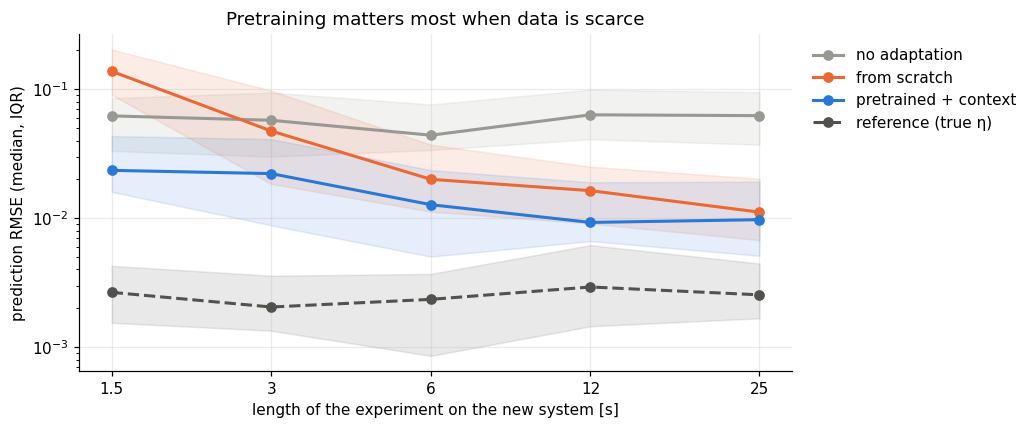

  1.5 s: from-scratch error is  5.9x the pretrained error
  3.0 s: from-scratch error is  2.1x the pretrained error
  6.0 s: from-scratch error is  1.6x the pretrained error
 12.0 s: from-scratch error is  1.8x the pretrained error
 25.0 s: from-scratch error is  1.1x the pretrained error


In [2]:
budgets = [15, 30, 60, 120, 250]                        # samples; x 0.1 s
methods = ["none", "scratch", "context", "reference"]
budget_err = {m: np.zeros((len(budgets), 40)) for m in methods}
for i, T in enumerate(budgets):
    for n in range(40):
        s = sample_system(rng); u = multisine(T, rng); _, y = simulate(s, u, rng)
        u_val = multisine(300, rng, n=6); q_val, _ = simulate(s, u_val, rng, noise=False)
        etas = dict(none=family.mean, scratch=fit_from_scratch(y, u),
                    context=family.decode(adapt(family, y, u)[0]), reference=s["eta"])
        for m in methods:
            budget_err[m][i, n] = rmse(predict(etas[m], u_val), q_val)

labels = dict(none="no adaptation", scratch="from scratch", context="pretrained + context",
              reference="reference (true η)")
seconds = dynutils.DT * np.array(budgets)
fig, ax = plt.subplots(figsize=(9.5, 4))
for m in methods:
    med = np.median(budget_err[m], axis=1)
    lo, hi = np.percentile(budget_err[m], [25, 75], axis=1)
    ls = "--" if m == "reference" else "-"
    ax.plot(seconds, med, ls, marker="o", color=COLOR[m], label=labels[m])
    ax.fill_between(seconds, lo, hi, color=COLOR[m], alpha=0.12)
ax.set(xscale="log", yscale="log", xlabel="length of the experiment on the new system [s]",
       ylabel="prediction RMSE (median, IQR)", xticks=seconds, xticklabels=[f"{x:g}" for x in seconds],
       title="Pretraining matters most when data is scarce")
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()

for i, T in enumerate(budgets):
    ratio = np.median(budget_err["scratch"][i]) / np.median(budget_err["context"][i])
    print(f"{T*dynutils.DT:5.1f} s: from-scratch error is {ratio:4.1f}x the pretrained error")

The pattern is the central message of few-shot learning:

- **Scarce data (a few seconds):** from scratch is worse than doing nothing, because it overfits.
  The pretrained model is already useful.
- **More data:** from scratch improves steadily and the gap narrows. Pretraining buys data
  efficiency, not a better final model.
- **All learned models stay above the reference.** The remaining error comes from the imperfect
  pretraining (e.g. the poorly identified $\alpha$) and the rank-2 restriction. Neither can be
  fixed by collecting more data on the new system; only a better model class can.

So far every experiment has been random. Can we do better by *choosing* the experiment?

---
## Exercises

### Exercise 1: Where exactly does from-scratch catch up?
Using the `budget_err` arrays above, find the smallest budget at which the median from-scratch error
drops below the median pretrained-context error (if it does within the budgets tried).

<details><summary>Solution</summary>

```python
med_scratch = np.median(budget_err["scratch"], axis=1)
med_context = np.median(budget_err["context"], axis=1)
crossing = [T for T, s, c in zip(budgets, med_scratch, med_context) if s < c]
crossing[:1] if crossing else "no crossing within the tried budgets"
```
Within the budgets tried (up to 25 s) from scratch does not fully close the gap on the median, even
though its *rate of improvement* is faster; the two curves are converging but the crossing, if any,
lies beyond 25 s.
</details>

### Exercise 2: Restricting the family to one dimension
Refit `family` with `rank=1` (reuse `train_fits`/`train_data` from chapter 03's recipe via
`dynutils.build_family(rng, rank=1)` on a fresh `rng`) and repeat the comparison at the shortest
budget only. How much worse does a one-number context do compared with the two-number one?

<details><summary>Solution</summary>

```python
rank1_family, *_ = dynutils.build_family(np.random.default_rng(dynutils.SEED), rank=1)
T = budgets[0]
errs = []
for n in range(40):
    s = sample_system(rng); u = multisine(T, rng); _, y = simulate(s, u, rng)
    u_val = multisine(300, rng, n=6); q_val, _ = simulate(s, u_val, rng, noise=False)
    z1, _, _ = adapt(rank1_family, y, u)
    errs.append(rmse(predict(rank1_family.decode(z1), u_val), q_val))
np.median(errs), np.median(budget_err["context"][0])
```
A single number cannot represent the second family direction at all, so systems whose true context
lies mostly along $z_2$ are systematically mispredicted; the one-dimensional context is
noticeably worse on the shortest budget, even though it is *more* certain about the number it does
estimate.
</details>